In [1]:
# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload
# Always reload modules so that as you change code in src, it gets loaded
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt


import src.utils.setup_figures as figures

In [3]:

# style = ["dark_background"]
# plt.style.use(style)
figures.setup()
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

### Utils

In [4]:
def timestamp_to_ms(pd_series):
    series = pd.to_datetime(pd_series, format="%H:%M:%S.%f")
    ms = (
        series.dt.hour * 3600 * 1000
        + series.dt.minute * 60 * 1000
        + series.dt.second * 1000
        + series.dt.microsecond // 1000
    )
    # convert series elements to float
    ms = ms.astype(float)
    return ms

In [5]:
session_data = pd.DataFrame()
session_licks = pd.DataFrame()

sessions = ['21_1']# ['18_1', '19_1', '20_2', '21_1']


for session_id in sessions:
    trial_data = pd.read_csv(rf"Y:\DBM22\data\random_dot_motion\rt_maintenance\{session_id}\DBM22_trial.csv", index_col=0)
    lick_data = pd.read_csv(rf"Y:\DBM22\data\random_dot_motion\rt_maintenance\{session_id}\DBM22_lick.csv", header=None)

    trial_data["session_id"] = session_id
    lick_data.columns = ['hw_time', 'session_time', 'trial_time', 'lick_type', 'lick_dur']
    lick_data['session_id'] = session_id
    lick_data['session_time'] *= 1000
    lick_data['trial_time'] *= 1000
    lick_data['lick_dur'] *= 1000
    # concatenate trial data to session_data
    session_data = pd.concat([session_data, trial_data])
    session_licks = pd.concat([session_licks, lick_data])

session_data.shape, session_licks.shape

((474, 23), (3264, 6))

In [6]:
session_data = pd.DataFrame()
session_licks = pd.DataFrame()

mouse_id = 'DBM23'
sessions = ["2_3"]  # ['18_1', '19_1', '20_2', '21_1']


for session_id in sessions:
    trial_data = pd.read_csv(rf"Y:\{mouse_id}\data\random_dot_motion\rt_directional_training\{session_id}\{mouse_id}_trial.csv", index_col=0)
    lick_data = pd.read_csv(rf"Y:\{mouse_id}\data\random_dot_motion\rt_directional_training\{session_id}\{mouse_id}_lick.csv", header=None)

    trial_data["session_id"] = session_id
    lick_data.columns = ["hw_time", "session_time", "trial_time", "lick_type", "lick_dur"]
    lick_data["session_id"] = session_id
    lick_data["session_time"] *= 1000
    lick_data["trial_time"] *= 1000
    lick_data["lick_dur"] *= 1000
    # concatenate trial data to session_data
    session_data = pd.concat([session_data, trial_data])
    session_licks = pd.concat([session_licks, lick_data])

session_data.shape, session_licks.shape

((338, 23), (2247, 6))

In [7]:
events = ["fixation_onset", "stimulus_onset", "response_onset", "reinforcement_onset", "delay_onset", "intertrial_onset"]

for event in events:
    session_data[event + "_ms"] = timestamp_to_ms(session_data[event])

session_data['fixation_onset_ms'] = session_data['stimulus_onset_ms'] - (session_data['fixation_duration'] * 1e3)
session_data["next_fixation_onset_ms"] = session_data["fixation_onset_ms"].shift(-1)


In [8]:
correct_trials = session_data[session_data["outcome"] == 1]
incorrect_trials = session_data[session_data["outcome"] == 0]
correct_trials.shape, incorrect_trials.shape

((232, 30), (87, 30))

In [9]:
events = ['fixation_onset', 'stimulus_onset', 'response_onset', 'reinforcement_onset', 'delay_onset', 'intertrial_onset']

for event in events:
    correct_trials[event + '_ms'] = timestamp_to_ms(correct_trials[event])
    incorrect_trials[event + '_ms'] = timestamp_to_ms(incorrect_trials[event])

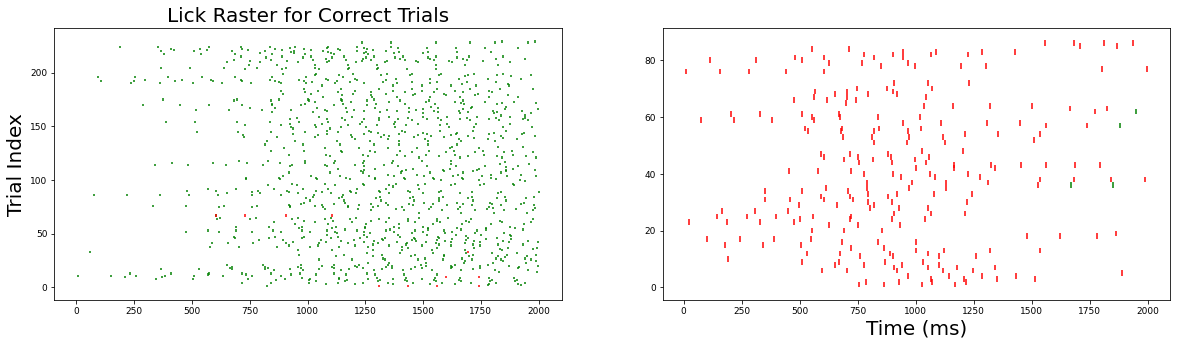

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

correct_trial_correct_lick = np.empty([len(correct_trials), 25000]) * np.NaN
correct_trial_incorrect_lick = np.empty([len(correct_trials), 25000]) * np.NaN


for idx_trial in range(1, len(correct_trials)):
    # trial variables
    trial_row = correct_trials.iloc[idx_trial]
    correct_choice = 2 * np.sign(trial_row["target"])
    incorrect_choice = -correct_choice

    # start = trial_row["fixation_onset_ms"]# - (trial_row["fixation_duration"] * 1000)
    start = trial_row["stimulus_onset_ms"]
    # start = trial_row["next_fixation_onset_ms"] - 1000  # trial_row["reinforcement_onset_ms"]
    end = trial_row["stimulus_onset_ms"] + 2000#trial_row["next_fixation_onset_ms"]  # + 2000

    # find where session_time in session_licks is between start and end
    licks = session_licks[(session_licks["session_time"] > start) & (session_licks["session_time"] < end)]
    # Define correct and incorrect choice licks
    correct_licks = licks[licks["lick_type"] == correct_choice]
    correct_trial_correct_lick[idx_trial, 0 : len(correct_licks)] = correct_licks["session_time"] - start
    if not correct_licks.empty:
        ax[0].vlines(correct_licks["session_time"] - start, idx_trial - 1, idx_trial + 1, color="g")

    incorrect_licks = licks[licks["lick_type"] == incorrect_choice]
    correct_trial_incorrect_lick[idx_trial, 0 : len(incorrect_licks)] = incorrect_licks["session_time"] - start
    if not incorrect_licks.empty:
        ax[0].vlines(incorrect_licks["session_time"] - start, idx_trial - 1, idx_trial + 1, color="r")

# fig, ax = plt.subplots(2, 1, figsize=(10, 10))

incorrect_trial_correct_lick = np.empty([len(incorrect_trials), 25000]) * np.NaN
incorrect_trial_incorrect_lick = np.empty([len(incorrect_trials), 25000]) * np.NaN

for idx_trial in range(1, len(incorrect_trials)):
    # trial variables
    trial_row = incorrect_trials.iloc[idx_trial]
    correct_choice = 2 * np.sign(trial_row["target"])
    incorrect_choice = -correct_choice

    # start = trial_row["fixation_onset_ms"]# - (trial_row["fixation_duration"] * 1000)
    start = trial_row["stimulus_onset_ms"]
    # start = trial_row["next_fixation_onset_ms"] - 1000  # trial_row["reinforcement_onset_ms"]
    end = trial_row["stimulus_onset_ms"] + 2000#trial_row["next_fixation_onset_ms"]# + 2000

    # find where session_time in session_licks is between start and end
    licks = session_licks[(session_licks["session_time"] > start) & (session_licks["session_time"] < end)]
    # Define correct and incorrect choice licks
    correct_licks = licks[licks["lick_type"] == correct_choice]
    incorrect_trial_correct_lick[idx_trial, 0 : len(correct_licks)] = correct_licks["session_time"] - start
    if not correct_licks.empty:
        ax[1].vlines(correct_licks["session_time"] - start, idx_trial - 1, idx_trial + 1, color="g")

    incorrect_licks = licks[licks["lick_type"] == incorrect_choice]
    incorrect_trial_incorrect_lick[idx_trial, 0 : len(incorrect_licks)] = incorrect_licks["session_time"] - start
    if not incorrect_licks.empty:
        ax[1].vlines(incorrect_licks["session_time"] - start, idx_trial - 1, idx_trial + 1, color="r")


# Add labels and grid for readability
plt.xlabel("Time (ms)", fontsize=20)
ax[0].set_ylabel("Trial Index", fontsize=20)
# ax[0].set_xlim(0, 1000)
ax[0].set_title("Lick Raster for Correct Trials", fontsize=20)
# ax[0].set_grid(axis="y", linestyle="--", alpha=0.5)

# ax[1].plot((np.nanmean(correct_trial_correct_lick, axis=0)))


plt.show()

### All trials plot

In [13]:
time_data = pd.DataFrame()

time_data['fixation_onset_ms'] = session_data['fixation_onset_ms'] - session_data['fixation_onset_ms']
time_data['stimulus_onset_ms'] = session_data['stimulus_onset_ms'] - session_data['fixation_onset_ms']
time_data["response_onset_ms"] = session_data["response_onset_ms"] - session_data["fixation_onset_ms"]
time_data["reinforcement_onset_ms"] = session_data["reinforcement_onset_ms"] - session_data["fixation_onset_ms"]
time_data["delay_onset_ms"] = session_data["delay_onset_ms"] - session_data["fixation_onset_ms"]
time_data["intertrial_onset_ms"] = session_data["intertrial_onset_ms"] - session_data["fixation_onset_ms"]
time_data["next_fixation_onset_ms"] = session_data["next_fixation_onset_ms"] - session_data["fixation_onset_ms"]

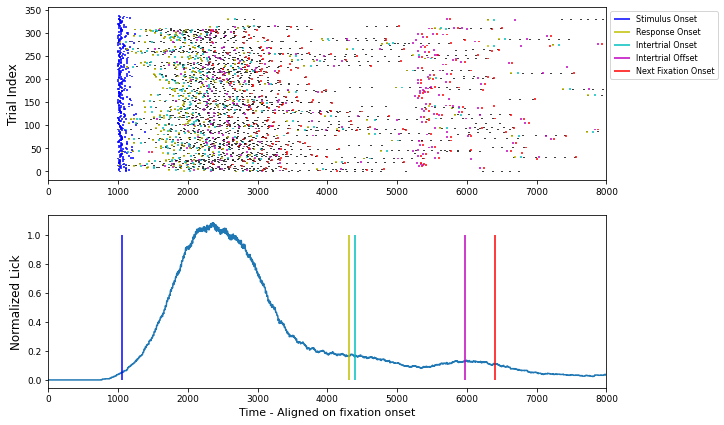

In [14]:
trial_length = 40000

all_trial_licks = np.empty([len(session_data), trial_length]) * np.NaN
correct_trial_lick = np.empty([len(session_data), trial_length]) * np.NaN
incorrect_trial_lick = np.empty([len(session_data), trial_length]) * np.NaN

fig, ax = plt.subplots(2, 1, figsize=(10, 7))
for idx_trial in range(len(session_data)):
    # trial variables
    trial_row = session_data.iloc[idx_trial]

    start = trial_row["fixation_onset_ms"]
    end = trial_row["next_fixation_onset_ms"]

    # end = trial_row["next_fixation_onset_ms"]+100

    # find where session_time in session_licks is between start and end
    licks = session_licks[(session_licks['session_time'] > start) & (session_licks['session_time'] < end)]
    all_trial_licks[idx_trial, (licks["session_time"] - start).astype(int)] = 1

    # Define correct and incorrect choice licks
    correct_choice = 2 * np.sign(trial_row["target"])
    incorrect_choice = -correct_choice
    correct_licks = licks[licks["lick_type"] == correct_choice]
    incorrect_licks = licks[licks["lick_type"] == incorrect_choice]
    correct_trial_lick[idx_trial, (correct_licks["session_time"] - start).astype(int)] = 1
    incorrect_trial_lick[idx_trial, (incorrect_licks["session_time"] - start).astype(int)] = -1

    # plot licks
    # Extract correct and incorrect lick indices
    correct_indices = np.where(correct_trial_lick[idx_trial, :] == 1)[0]
    incorrect_indices = np.where(incorrect_trial_lick[idx_trial, :] == -1)[0]
    ax[0].vlines(correct_indices, idx_trial - 1, idx_trial + 1, color="k")#, label="Correct Licks")
    ax[0].vlines(incorrect_indices, idx_trial - 1, idx_trial + 1, color="k")  # , label="Incorrect Licks")

    ax[0].vlines(trial_row["stimulus_onset_ms"] - start, idx_trial - 2, idx_trial + 2, color="b")
    ax[0].vlines(trial_row["response_onset_ms"] - start, idx_trial - 2, idx_trial + 2, color="y")
    ax[0].vlines(trial_row["intertrial_onset_ms"] - start, idx_trial - 2, idx_trial + 2, color="c")
    ax[0].vlines(trial_row["intertrial_onset_ms"] - start + (session_data['intertrial_duration'].iloc[idx_trial] * 1e3), idx_trial - 2, idx_trial + 2, color="m")
    ax[0].vlines(trial_row["next_fixation_onset_ms"] - start, idx_trial - 2, idx_trial + 2, color="r")


ax[0].vlines(0, 0, 0, color="b", label="Stimulus Onset")
ax[0].vlines(0, 0, 0, color="y", label="Response Onset")
ax[0].vlines(0, 0, 0, color="c", label="Intertrial Onset")
ax[0].vlines(0, 0, 0, color="m", label="Intertrial Offset")
ax[0].vlines(0, 0, 0, color="r", label="Next Fixation Onset")

ax[1].plot(np.convolve(np.nansum(all_trial_licks, axis=0), np.ones(500) / 500, mode="same"))

start = np.nanmean(session_data["fixation_onset_ms"])
ax[1].vlines(np.nanmean(time_data["stimulus_onset_ms"]), 0, 1, color="b", label="Stimulus Onset")
ax[1].vlines(np.nanmean(time_data["response_onset_ms"]), 0, 1, color="y", label="Response Onset")
ax[1].vlines(np.nanmean(time_data["intertrial_onset_ms"]), 0, 1, color="c", label="Intertrial Onset")
ax[1].vlines(
    np.nanmean(time_data["intertrial_onset_ms"]) + np.nanmean(session_data["intertrial_duration"] * 1e3),
    0,
    1,
    color="m",
    label="Intertrial Offset",
)
ax[1].vlines(np.nanmean(time_data["next_fixation_onset_ms"]), 0, 1, color="r", label="Next Fixation Onset")

ax[0].set_ylabel("Trial Index", fontsize=12)
ax[1].set_ylabel("Normalized Lick", fontsize=12)
ax[1].set_xlabel("Time - Aligned on fixation onset", fontsize=11)
ax[0].legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
ax[0].set_xlim(0, 8000)
ax[1].set_xlim(0, 8000)
plt.show()

### Aligned on reward onset

In [15]:
time_data = pd.DataFrame()

time_data["fixation_onset_ms"] = session_data["fixation_onset_ms"] - session_data["response_onset_ms"]
time_data["stimulus_onset_ms"] = session_data["stimulus_onset_ms"] - session_data["response_onset_ms"]
time_data["response_onset_ms"] = session_data["response_onset_ms"] - session_data["response_onset_ms"]
time_data["reinforcement_onset_ms"] = session_data["reinforcement_onset_ms"] - session_data["response_onset_ms"]
time_data["delay_onset_ms"] = session_data["delay_onset_ms"] - session_data["response_onset_ms"]
time_data["intertrial_onset_ms"] = session_data["intertrial_onset_ms"] - session_data["response_onset_ms"]
time_data["next_fixation_onset_ms"] = session_data["next_fixation_onset_ms"] - session_data["response_onset_ms"]

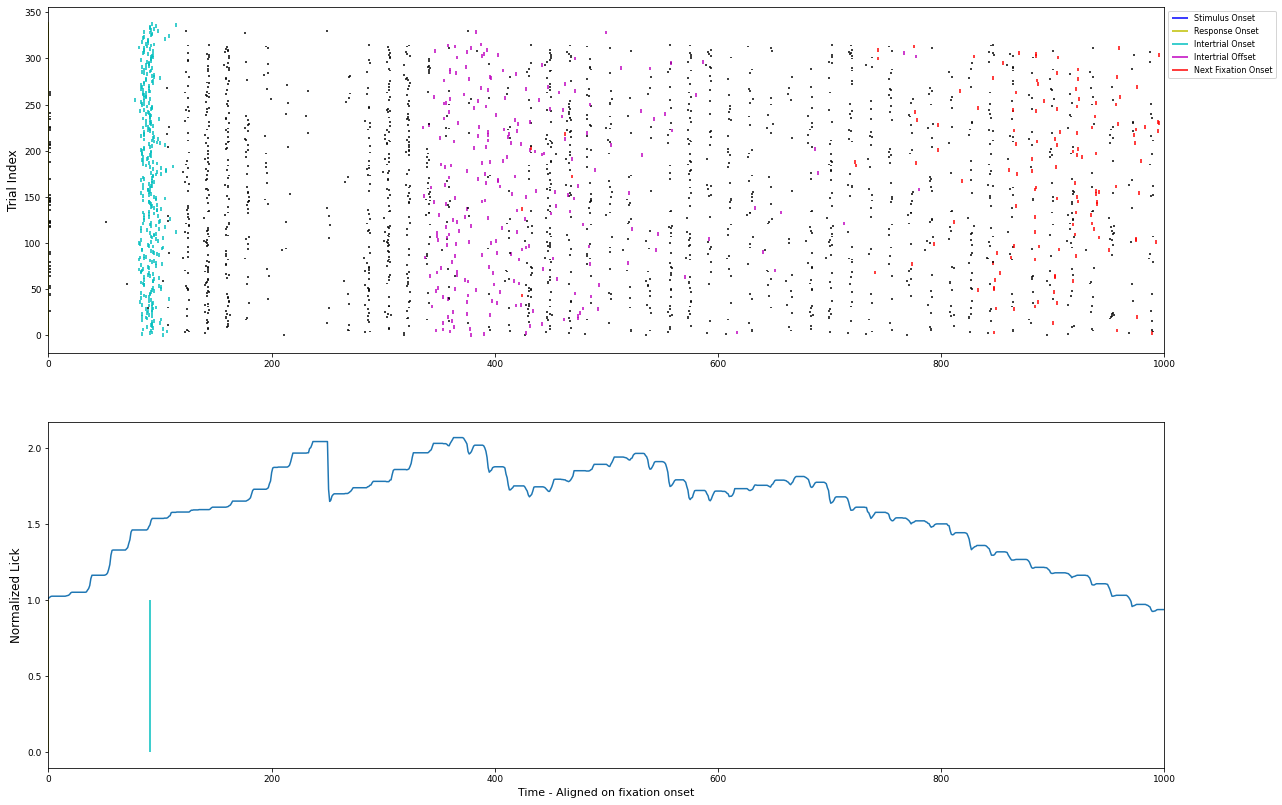

In [18]:
trial_length = 40000

all_trial_licks = np.empty([len(session_data), trial_length]) * np.NaN
correct_trial_lick = np.empty([len(session_data), trial_length]) * np.NaN
incorrect_trial_lick = np.empty([len(session_data), trial_length]) * np.NaN

fig, ax = plt.subplots(2, 1, figsize=(20, 14))
for idx_trial in range(len(session_data)):
    # trial variables
    trial_row = session_data.iloc[idx_trial]

    start = trial_row["response_onset_ms"]
    end = trial_row["next_fixation_onset_ms"]

    # end = trial_row["next_fixation_onset_ms"]+100

    # find where session_time in session_licks is between start and end
    licks = session_licks[(session_licks['session_time'] > start) & (session_licks['session_time'] < end)]
    all_trial_licks[idx_trial, (licks["session_time"] - start).astype(int)] = 1

    # Define correct and incorrect choice licks
    correct_choice = 2 * np.sign(trial_row["target"])
    incorrect_choice = -correct_choice
    correct_licks = licks[licks["lick_type"] == correct_choice]
    incorrect_licks = licks[licks["lick_type"] == incorrect_choice]
    correct_trial_lick[idx_trial, (correct_licks["session_time"] - start).astype(int)] = 1
    incorrect_trial_lick[idx_trial, (incorrect_licks["session_time"] - start).astype(int)] = -1

    # plot licks
    # Extract correct and incorrect lick indices
    correct_indices = np.where(correct_trial_lick[idx_trial, :] == 1)[0]
    incorrect_indices = np.where(incorrect_trial_lick[idx_trial, :] == -1)[0]
    ax[0].vlines(correct_indices, idx_trial - 1, idx_trial + 1, color="k")#, label="Correct Licks")
    ax[0].vlines(incorrect_indices, idx_trial - 1, idx_trial + 1, color="k")  # , label="Incorrect Licks")

    ax[0].vlines(trial_row["stimulus_onset_ms"] - start, idx_trial - 2, idx_trial + 2, color="b")
    ax[0].vlines(trial_row["response_onset_ms"] - start, idx_trial - 2, idx_trial + 2, color="y")
    ax[0].vlines(trial_row["intertrial_onset_ms"] - start, idx_trial - 2, idx_trial + 2, color="c")
    ax[0].vlines(trial_row["intertrial_onset_ms"] - start + (session_data['intertrial_duration'].iloc[idx_trial] * 1e3), idx_trial - 2, idx_trial + 2, color="m")
    ax[0].vlines(trial_row["next_fixation_onset_ms"] - start, idx_trial - 2, idx_trial + 2, color="r")


ax[0].vlines(0, 0, 0, color="b", label="Stimulus Onset")
ax[0].vlines(0, 0, 0, color="y", label="Response Onset")
ax[0].vlines(0, 0, 0, color="c", label="Intertrial Onset")
ax[0].vlines(0, 0, 0, color="m", label="Intertrial Offset")
ax[0].vlines(0, 0, 0, color="r", label="Next Fixation Onset")

ax[1].plot(np.convolve(np.nansum(all_trial_licks, axis=0), np.ones(500) / 500, mode="same"))

start = np.nanmean(session_data["fixation_onset_ms"])
ax[1].vlines(np.nanmean(time_data["stimulus_onset_ms"]), 0, 1, color="b", label="Stimulus Onset")
ax[1].vlines(np.nanmean(time_data["response_onset_ms"]), 0, 1, color="y", label="Response Onset")
ax[1].vlines(np.nanmean(time_data["intertrial_onset_ms"]), 0, 1, color="c", label="Intertrial Onset")
ax[1].vlines(
    np.nanmean(time_data["intertrial_onset_ms"]) + np.nanmean(session_data["intertrial_duration"] * 1e3),
    0,
    1,
    color="m",
    label="Intertrial Offset",
)
ax[1].vlines(np.nanmean(time_data["next_fixation_onset_ms"]), 0, 1, color="r", label="Next Fixation Onset")

ax[0].set_ylabel("Trial Index", fontsize=12)
ax[1].set_ylabel("Normalized Lick", fontsize=12)
ax[1].set_xlabel("Time - Aligned on fixation onset", fontsize=11)
ax[0].legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
ax[0].set_xlim(0, 1000)
ax[1].set_xlim(0, 1000)
plt.show()